# AI Hardware Architecture

**Author:** Nitin Sarangdhar  
**Affiliation:** SemiX Visiting Professor of practice | IIT Bombay  
**Date:** March 2026  

Designing a 2-Layer CNN for MNIST Classification

### Objective
To architect, implement, and analyze a 2-layer Convolutional Neural Network (CNN) using **PyTorch**. This lab transitions from basic edge detection to multi-class digit recognition (0–9), with a specific focus on **hardware-software co-design** and the trade-offs of deep learning silicon.

---

### 1. Architecture Specification
Build a network with the following pipeline. Pay close attention to the **SRAM footprint** and **MAC (Multiply-Accumulate)** requirements of each stage.

| Layer | Type | Configuration | Hardware Role |
| :--- | :--- | :--- | :--- |
| **Input** | Grayscale | 1 Channel, 28x28 pixels | Raw Data Stream |
| **Conv 1** | Convolution | 32 Filters, 3x3 Kernel, Bias=True | Low-level feature extraction (Edges) |
| **ReLU 1** | Activation | Element-wise $\max(0, x)$ | Non-linear "Feature Cleaning" |
| **Pool 1** | Max Pooling | 2x2 Window, Stride 2 | Spatial Compression (28x28 $\rightarrow$ 14x14) |
| **Conv 2** | Convolution | 64 Filters, 3x3 Kernel, Bias=True | Mid-level feature extraction (Shapes) |
| **ReLU 2** | Activation | Element-wise $\max(0, x)$ | Introducing **Sparsity** |
| **Pool 2** | Max Pooling | 2x2 Window, Stride 2 | Spatial Compression (14x14 $\rightarrow$ 7x7) |
| **Flatten** | Reshape | 1D Vector ($64 \times 5 \times 5$) | Memory alignment for Dense layer |
| **FC 1** | Fully Connected | 128 Neurons | High-level reasoning |
| **FC 2** | Output Layer | 10 Neurons (Digits 0–9) | Final Class Scoring (Logits) |

---

### 2. The Dual Role of ReLU in Silicon
In this assignment, we analyze how the mathematical ReLU function ($y = \max(0, x)$) serves two distinct architectural purposes depending on its depth in the pipeline:

| Stage | Functional Role | Architectural Impact |
| :--- | :--- | :--- |
| **ReLU 1** | **Feature Cleaning** | Acts as a **"noise gate"** for raw pixels. It removes negative gradients and "background hiss," ensuring the next layer receives only high-contrast, meaningful edges. |
| **ReLU 2** | **Sparsity Generation** | Facilitates **deep-layer selectivity**. It forces the network to be "sparse" (mostly zeros), allowing sparsity-aware hardware to skip redundant MAC operations and save power. |

---



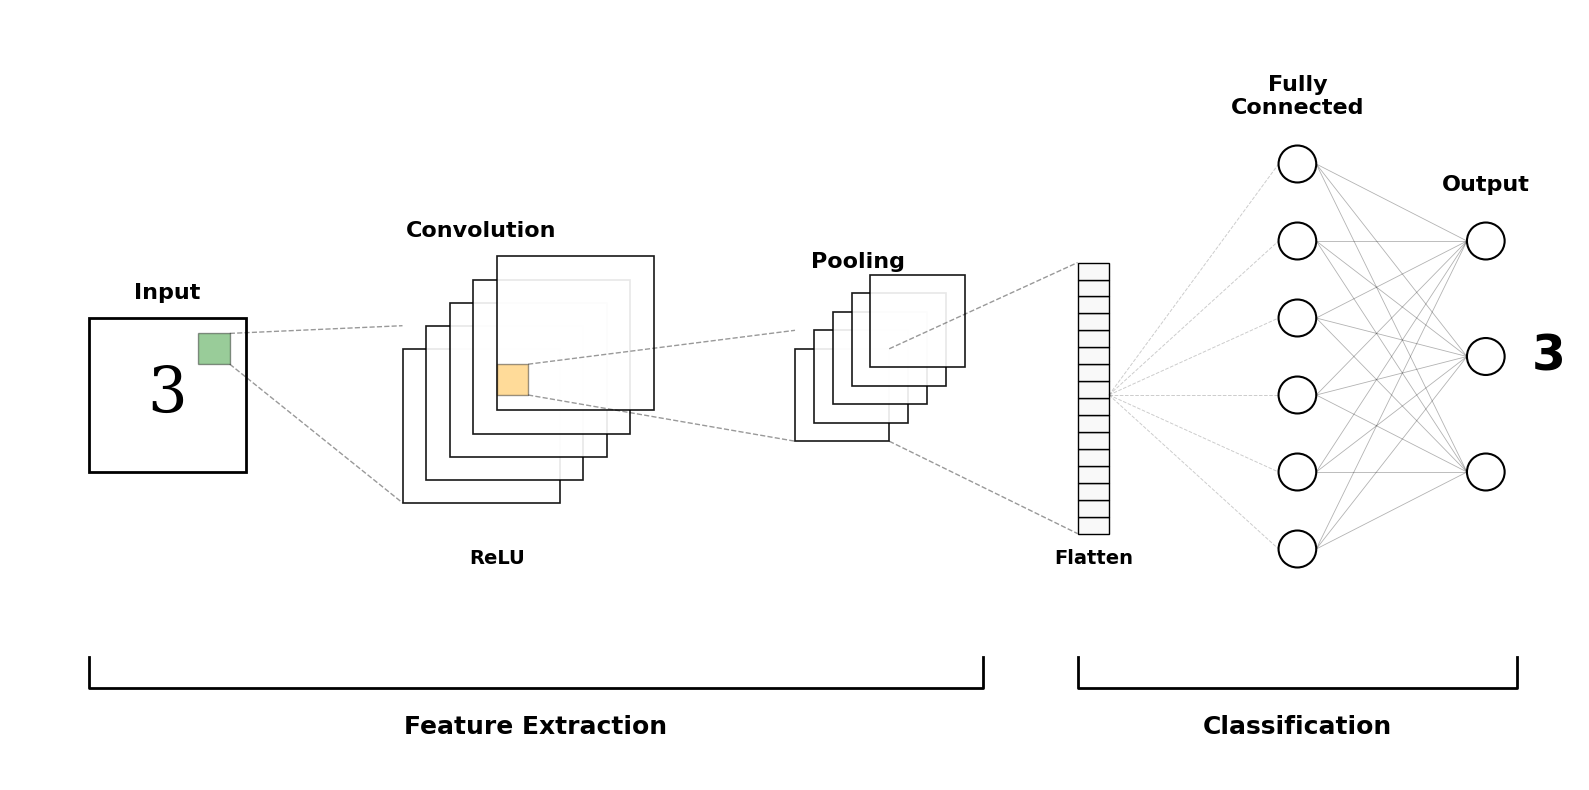

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_cnn_architecture():
    # Set up the figure
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 50)
    ax.axis('off')

    # Font settings
    header_style = {'ha': 'center', 'va': 'bottom', 'fontsize': 16, 'fontweight': 'bold'}
    brace_style = {'fontsize': 18, 'fontweight': 'bold', 'ha': 'center'}

    # --- 1. INPUT LAYER ---
    ax.add_patch(patches.Rectangle((5, 20), 10, 10, fill=False, lw=2))
    ax.text(10, 31, "Input", **header_style)
    # Drawing a '3' inside to mimic MNIST
    ax.text(10, 25, "3", fontsize=45, ha='center', va='center', family='serif')
    # Kernel selection box
    ax.add_patch(patches.Rectangle((12, 27), 2, 2, facecolor='green', alpha=0.4, edgecolor='black'))

    # --- 2. CONVOLUTION LAYER (Stacked Feature Maps) ---
    for i in range(5):
        ax.add_patch(patches.Rectangle((25 + i*1.5, 18 + i*1.5), 10, 10,
                                      facecolor='white', edgecolor='black', lw=1.2, alpha=0.9))
    ax.text(30, 35, "Convolution", **header_style)
    ax.text(31, 14, "ReLU", fontsize=14, fontweight='bold', ha='center')
    # Feature map selection box
    ax.add_patch(patches.Rectangle((31, 25), 2, 2, facecolor='orange', alpha=0.4, edgecolor='black'))

    # --- 3. POOLING LAYER ---
    for i in range(5):
        ax.add_patch(patches.Rectangle((50 + i*1.2, 22 + i*1.2), 6, 6,
                                      facecolor='white', edgecolor='black', lw=1.2, alpha=0.9))
    ax.text(54, 33, "Pooling", **header_style)

    # --- 4. FLATTEN LAYER (Vertical Vector) ---
    flatten_x = 68
    num_elements = 16
    elem_h = 1.1
    for i in range(num_elements):
        ax.add_patch(patches.Rectangle((flatten_x, 16 + i*elem_h), 2, elem_h,
                                      facecolor='#f9f9f9', edgecolor='black', lw=1))
    ax.text(69, 14, "Flatten", ha='center', fontsize=14, fontweight='bold')

    # --- 5. FULLY CONNECTED LAYER ---
    fc_x = 82
    fc_y_coords = np.linspace(15, 40, 6)
    for y in fc_y_coords:
        ax.add_patch(patches.Circle((fc_x, y), 1.2, edgecolor='black', facecolor='white', lw=1.5))
    ax.text(fc_x, 43, "Fully\nConnected", **header_style)

    # --- 6. OUTPUT LAYER ---
    out_x = 94
    out_y_coords = np.linspace(20, 35, 3)
    for y in out_y_coords:
        ax.add_patch(patches.Circle((out_x, y), 1.2, edgecolor='black', facecolor='white', lw=1.5))
    ax.text(out_x, 38, "Output", **header_style)
    ax.text(98, 27.5, "3", fontsize=35, ha='center', va='center', fontweight='bold')

    # --- CONNECTIONS ---
    # Projection lines: Input to Conv
    ax.plot([14, 25], [29, 29.5], 'k--', lw=1, alpha=0.4)
    ax.plot([14, 25], [27, 18], 'k--', lw=1, alpha=0.4)
    # Projection lines: Conv to Pool
    ax.plot([33, 50], [27, 29.2], 'k--', lw=1, alpha=0.4)
    ax.plot([33, 50], [25, 22], 'k--', lw=1, alpha=0.4)
    # Projection lines: Pool to Flatten
    ax.plot([56, flatten_x], [28, 33.6], 'k--', lw=1, alpha=0.4)
    ax.plot([56, flatten_x], [22, 16], 'k--', lw=1, alpha=0.4)
    # Dense connections: Flatten to FC
    for y in fc_y_coords:
        ax.plot([flatten_x + 2, fc_x - 1.2], [25, y], 'k--', lw=0.7, alpha=0.2)
    # Dense connections: FC to Output
    for yf in fc_y_coords:
        for yo in out_y_coords:
            ax.plot([fc_x + 1.2, out_x - 1.2], [yf, yo], 'k-', lw=0.6, alpha=0.3)

    # --- BOTTOM BRACKETS (Braces) ---
    # Feature Extraction Brace
    ax.plot([5, 5, 62, 62], [8, 6, 6, 8], color='black', lw=2)
    ax.text(33.5, 3, "Feature Extraction", **brace_style)
    # Classification Brace
    ax.plot([68, 68, 96, 96], [8, 6, 6, 8], color='black', lw=2)
    ax.text(82, 3, "Classification", **brace_style)

    plt.tight_layout()
    plt.savefig('cnn_architecture_mnist.png', dpi=300, bbox_inches='tight')
    plt.show()

draw_cnn_architecture()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- 1. HARDWARE-AWARE ARCHITECTURE ---
class MNISTHardwareModel(nn.Module):
    def __init__(self):
        super(MNISTHardwareModel, self).__init__()

        # Layer 1: Feature Cleaning (32 Filters, 3x3)
        # Input: 28x28 -> Conv(3x3): 26x26 -> Pool(2x2): 13x13
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, bias=True)

        # Layer 2: Sparsity Generation (64 Filters, 3x3)
        # Input: 13x13 -> Conv(3x3): 11x11 -> Pool(2x2): 5x5
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, bias=True)

        self.pool = nn.MaxPool2d(2, 2)

        # Classifier (Vector-Matrix Multiplication)
        # Flattened Input: 64 filters * 5px * 5px = 1600 elements
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Stage 1: Conv -> ReLU (Clean) -> Pool
        x = self.pool(torch.relu(self.conv1(x)))

        # Stage 2: Conv -> ReLU (Sparse) -> Pool
        x = self.pool(torch.relu(self.conv2(x)))

        # Bridge: Flatten 2D Feature Maps to 1D Vector
        x = torch.flatten(x, 1)

        # Stage 3: Dense Reasoning
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# --- 2. DATA PREPARATION ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Standard MNIST mean/std
])

train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

# --- 3. TRAINING SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTHardwareModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- 4. MINI-TRAINING LOOP (3 Epochs) ---
model.train()
for epoch in range(1, 4):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()      # Reset Gradients
        output = model(data)       # Forward Pass
        loss = criterion(output, target) # Calculate Error
        loss.backward()            # Backpropagation (Using grad_fn)
        optimizer.step()           # Update Weights (SGD/Adam)

        running_loss += loss.item()
        if batch_idx % 200 == 199:
            print(f"Epoch {epoch} | Batch {batch_idx+1} | Loss: {running_loss/200:.4f}")
            running_loss = 0.0

print("\nTraining Complete. The model is now an optimized digit classifier!")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.68MB/s]


Device: cuda
Total Parameters: 225,034
Epoch 1 | Batch 200 | Loss: 0.3579
Epoch 1 | Batch 400 | Loss: 0.1013
Epoch 1 | Batch 600 | Loss: 0.0766
Epoch 1 | Batch 800 | Loss: 0.0626
Epoch 2 | Batch 200 | Loss: 0.0437
Epoch 2 | Batch 400 | Loss: 0.0419
Epoch 2 | Batch 600 | Loss: 0.0417
Epoch 2 | Batch 800 | Loss: 0.0455
Epoch 3 | Batch 200 | Loss: 0.0287
Epoch 3 | Batch 400 | Loss: 0.0311
Epoch 3 | Batch 600 | Loss: 0.0316
Epoch 3 | Batch 800 | Loss: 0.0271

Training Complete. The model is now an optimized digit classifier!


Target Digit: 9 | Model Prediction: 9


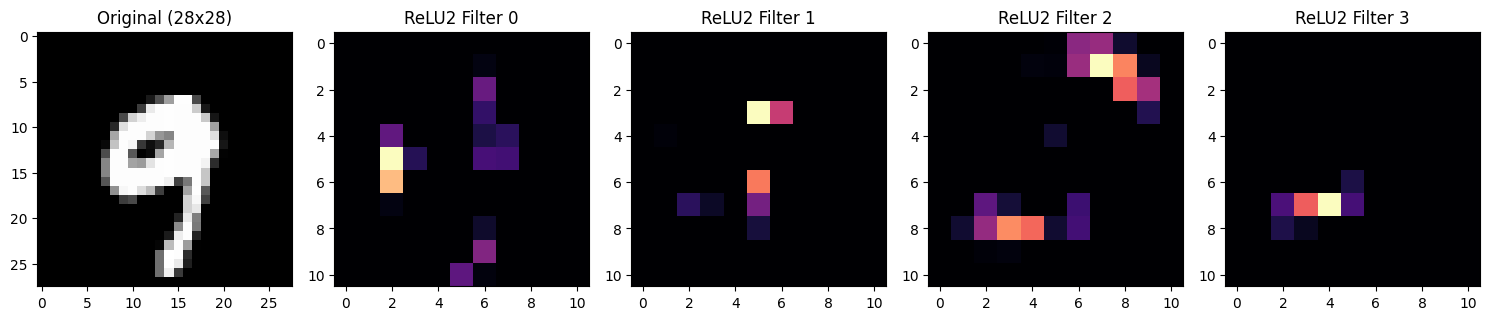

--- Hardware Sparsity Report ---
Total Pixels in ReLU2 Layer: 7744
Zero Pixels (Inactive):      7072
Sparsity Level:              91.32%


In [ ]:
import matplotlib.pyplot as plt
import torch

# --- 1. PREPARE A SAMPLE IMAGE ---
# Get one batch from the train_loader we defined earlier
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Select a single image (e.g., the first one in the batch)
test_image = images[0].unsqueeze(0).to(device)
true_label = labels[0].item()

# --- 2. EXTRACT INTERMEDIATE ACTIVATIONS ---
# We run the forward pass manually to 'catch' the output after ReLU2
model.eval() # Set to evaluation mode
with torch.no_grad():
    # Step-by-step pass
    x_conv1 = torch.relu(model.conv1(test_image))
    x_pool1 = model.pool(x_conv1)

    x_conv2 = torch.relu(model.conv2(x_pool1)) # This is the ReLU2 stage

    # Final prediction for context
    output = model(test_image)
    prediction = torch.argmax(output, dim=1).item()

# --- 3. VISUALIZATION ---
print(f"Target Digit: {true_label} | Model Prediction: {prediction}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Plot 1: Original Image
axes[0].imshow(test_image.cpu().squeeze(), cmap='gray')
axes[0].set_title("Original (28x28)")

# Plot 2-5: Selection of 4 Filters from ReLU2
# We have 64 filters; let's look at a few to see the 'Sparsity'
for i in range(4):
    filter_map = x_conv2[0, i].cpu().numpy()
    axes[i+1].imshow(filter_map, cmap='magma')
    axes[i+1].set_title(f"ReLU2 Filter {i}")

plt.tight_layout()
plt.show()

# --- 4. SPARSITY CHECK (The Hardware Metric) ---
total_elements = x_conv2.numel()
zero_elements = (x_conv2 == 0).sum().item()
sparsity_percentage = (zero_elements / total_elements) * 100

print(f"--- Hardware Sparsity Report ---")
print(f"Total Pixels in ReLU2 Layer: {total_elements}")
print(f"Zero Pixels (Inactive):      {zero_elements}")
print(f"Sparsity Level:              {sparsity_percentage:.2f}%")

Assignment Section: Hardware Resource Analysis
Task: For each layer of the MNISTHardwareModel, calculate the total memory required to store parameters and the total number of arithmetic operations (MACs) required for a single inference pass.

Hardware Parallelization & The "Batching" Effect
Objective: To observe how the hardware processes multiple images simultaneously to maximize the utilization of parallel Arithmetic Logic Units (ALUs).

The Concept: Serial vs. Parallel Throughput
In your code, we use a batch_size=64. From a hardware perspective, this means the NPU/GPU is not processing one digit, then the next. Instead, it is loading the same weight tensors once and applying them to 64 different image tensors in parallel.